# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot configuration
sns.set_theme(rc={'figure.dpi': 300})

# Read dataset

In [2]:
df = pd.read_csv("clean_dataset.csv", parse_dates=[0])
df

,record_date,avg_temp,hi_temp,low_temp,out_hum,dew_pt,wind_speed,wind_direction,wind_run,hi_speed,...,in_hum,in_dew,in_heat,in_emc,in_air_density,et,wind_samp,wind_tx,iss_recept,arc_int
0,2008-01-18 03:45:00,15.0,15.0,14.9,74.0,10.4,0.0,Calm,0.00,0.0,...,43.0,12.9,26.2,8.05,1.1588,0.00,351,1,100.0,15
1,2008-01-18 04:00:00,14.8,15.0,14.7,75.0,10.4,0.0,Calm,0.00,0.0,...,44.0,13.1,26.1,8.16,1.1588,0.03,352,1,100.0,15
2,2008-01-18 04:15:00,14.5,14.7,14.4,76.0,10.3,0.0,Calm,0.00,0.0,...,44.0,13.0,25.9,8.17,1.1597,0.00,351,1,100.0,15
3,2008-01-18 04:30:00,14.3,14.4,14.3,76.0,10.2,0.0,S,0.00,1.6,...,44.0,12.9,25.8,8.17,1.1602,0.00,351,1,100.0,15
4,2008-01-18 04:45:00,14.2,14.3,14.1,76.0,10.0,0.0,Calm,0.00,0.0,...,44.0,12.8,25.7,8.18,1.1609,0.00,351,1,100.0,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632404,2026-04-28 16:00:00,25.2,25.5,25.2,25.0,3.7,9.7,SE,2.41,24.1,...,34.0,2.8,17.3,6.85,1.1988,0.38,351,1,100.0,15
632405,2026-04-28 16:15:00,24.7,25.2,24.7,27.0,4.5,9.7,ESE,2.41,22.5,...,34.0,2.9,17.4,6.85,1.1983,0.00,352,1,100.0,15
632406,2026-04-28 16:30:00,24.0,24.7,24.0,29.0,4.9,9.7,SE,2.41,25.7,...,35.0,3.4,17.5,7.05,1.1979,0.00,351,1,100.0,15
632407,2026-04-28 16:45:00,22.8,24.0,22.8,33.0,5.7,11.3,ESE,2.82,25.7,...,35.0,3.4,17.6,7.05,1.1978,0.00,347,1,100.0,15


# Wind Direction
## Checking values

In [3]:
df["wind_direction"].value_counts()

wind_direction
Calm    219798
ESE      58244
SE       57264
NE       53335
ENE      43726
NNE      29426
E        25536
N        22093
W        20781
NNW      17426
SSW      15629
SSE      15497
S        15061
SW       10478
NW        9960
WSW       9290
WNW       8865
Name: count, dtype: int64

## Transforming using sine and cosine functions
Note that cyclic variables have a repeating pattern over a defined interval. In ML, capturing their nature could be challenging to do.

Therefore, an approach to solve this problem is using sine and cosine functions to transform the cyclical variable into two new components that preserve cyclicity.

In [4]:
dir_trig = {
    "N":    [np.sin(np.deg2rad(0)), np.cos(np.deg2rad(0))],
    "NNE":  [np.sin(np.deg2rad(22.5)), np.cos(np.deg2rad(22.5))],
    "NE":   [np.sin(np.deg2rad(45)), np.cos(np.deg2rad(45))],
    "ENE":  [np.sin(np.deg2rad(67.5)), np.cos(np.deg2rad(67.5))],
    "E":    [np.sin(np.deg2rad(90)), np.cos(np.deg2rad(90))],
    "ESE":  [np.sin(np.deg2rad(112.5)), np.cos(np.deg2rad(112.5))],
    "SE":   [np.sin(np.deg2rad(135)), np.cos(np.deg2rad(135))],
    "SSE":  [np.sin(np.deg2rad(157.5)), np.cos(np.deg2rad(157.5))],
    "S":    [np.sin(np.deg2rad(180)), np.cos(np.deg2rad(180))],
    "SSW":  [np.sin(np.deg2rad(202.5)), np.cos(np.deg2rad(202.5))],
    "SW":   [np.sin(np.deg2rad(225)), np.cos(np.deg2rad(225))],
    "WSW":  [np.sin(np.deg2rad(247.5)), np.cos(np.deg2rad(247.5))],
    "W":    [np.sin(np.deg2rad(270)), np.cos(np.deg2rad(270))],
    "WNW":  [np.sin(np.deg2rad(292.5)), np.cos(np.deg2rad(292.5))],
    "NW":   [np.sin(np.deg2rad(315)), np.cos(np.deg2rad(315))],
    "NNW":  [np.sin(np.deg2rad(337.5)), np.cos(np.deg2rad(337.5))],
    "Calm": [0,0]
}
df["wind_direction_x"] = df["wind_direction"].map(lambda x: dir_trig[x][0])
df["wind_direction_y"] = df["wind_direction"].map(lambda x: dir_trig[x][1])
df["wind_hi_dir_x"] = df["hi_dir"].map(lambda x: dir_trig[x][0])
df["wind_hi_dir_y"] = df["hi_dir"].map(lambda x: dir_trig[x][1])
df.drop(columns=["wind_direction","hi_dir"], inplace=True)
df

,record_date,avg_temp,hi_temp,low_temp,out_hum,dew_pt,wind_speed,wind_run,hi_speed,wind_chill,...,in_air_density,et,wind_samp,wind_tx,iss_recept,arc_int,wind_direction_x,wind_direction_y,wind_hi_dir_x,wind_hi_dir_y
0,2008-01-18 03:45:00,15.0,15.0,14.9,74.0,10.4,0.0,0.00,0.0,15.0,...,1.1588,0.00,351,1,100.0,15,0.000000e+00,0.000000,0.000000e+00,0.000000
1,2008-01-18 04:00:00,14.8,15.0,14.7,75.0,10.4,0.0,0.00,0.0,14.8,...,1.1588,0.03,352,1,100.0,15,0.000000e+00,0.000000,0.000000e+00,0.000000
2,2008-01-18 04:15:00,14.5,14.7,14.4,76.0,10.3,0.0,0.00,0.0,14.5,...,1.1597,0.00,351,1,100.0,15,0.000000e+00,0.000000,0.000000e+00,0.000000
3,2008-01-18 04:30:00,14.3,14.4,14.3,76.0,10.2,0.0,0.00,1.6,14.3,...,1.1602,0.00,351,1,100.0,15,1.224647e-16,-1.000000,1.224647e-16,-1.000000
4,2008-01-18 04:45:00,14.2,14.3,14.1,76.0,10.0,0.0,0.00,0.0,14.2,...,1.1609,0.00,351,1,100.0,15,0.000000e+00,0.000000,0.000000e+00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632404,2026-04-28 16:00:00,25.2,25.5,25.2,25.0,3.7,9.7,2.41,24.1,25.2,...,1.1988,0.38,351,1,100.0,15,7.071068e-01,-0.707107,3.826834e-01,-0.923880
632405,2026-04-28 16:15:00,24.7,25.2,24.7,27.0,4.5,9.7,2.41,22.5,24.7,...,1.1983,0.00,352,1,100.0,15,9.238795e-01,-0.382683,1.224647e-16,-1.000000
632406,2026-04-28 16:30:00,24.0,24.7,24.0,29.0,4.9,9.7,2.41,25.7,24.0,...,1.1979,0.00,351,1,100.0,15,7.071068e-01,-0.707107,7.071068e-01,-0.707107
632407,2026-04-28 16:45:00,22.8,24.0,22.8,33.0,5.7,11.3,2.82,25.7,22.8,...,1.1978,0.00,347,1,100.0,15,9.238795e-01,-0.382683,7.071068e-01,-0.707107


# Record Date
## Transforming using sine and cosine functions

In [5]:
record_date_month = df["record_date"].dt.month
record_date_day = df["record_date"].dt.dayofyear
record_date_hour = df['record_date'].dt.hour
record_date_minutes = df['record_date'].dt.minute/60
time_of_day = record_date_hour+record_date_minutes

# Month Cycle
df['month_sin'] = np.sin(2 * np.pi * ((record_date_month-1) / 12))
df['month_cos'] = np.cos(2 * np.pi * ((record_date_month-1) / 12))

# Day Cycle
df['day_sin'] = np.sin(2 * np.pi * ((record_date_day-1) / 365.25))
df['day_cos'] = np.cos(2 * np.pi * ((record_date_day-1) / 365.25))

# Hour/Minute Cycle
df['time_sin'] = np.sin(2 * np.pi * (time_of_day / 24))
df['time_cos'] = np.cos(2 * np.pi * (time_of_day / 24))
df

,record_date,avg_temp,hi_temp,low_temp,out_hum,dew_pt,wind_speed,wind_run,hi_speed,wind_chill,...,wind_direction_x,wind_direction_y,wind_hi_dir_x,wind_hi_dir_y,month_sin,month_cos,day_sin,day_cos,time_sin,time_cos
0,2008-01-18 03:45:00,15.0,15.0,14.9,74.0,10.4,0.0,0.00,0.0,15.0,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.0,1.000000e+00,0.288291,0.957543,0.831470,0.555570
1,2008-01-18 04:00:00,14.8,15.0,14.7,75.0,10.4,0.0,0.00,0.0,14.8,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.0,1.000000e+00,0.288291,0.957543,0.866025,0.500000
2,2008-01-18 04:15:00,14.5,14.7,14.4,76.0,10.3,0.0,0.00,0.0,14.5,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.0,1.000000e+00,0.288291,0.957543,0.896873,0.442289
3,2008-01-18 04:30:00,14.3,14.4,14.3,76.0,10.2,0.0,0.00,1.6,14.3,...,1.224647e-16,-1.000000,1.224647e-16,-1.000000,0.0,1.000000e+00,0.288291,0.957543,0.923880,0.382683
4,2008-01-18 04:45:00,14.2,14.3,14.1,76.0,10.0,0.0,0.00,0.0,14.2,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.0,1.000000e+00,0.288291,0.957543,0.946930,0.321439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632404,2026-04-28 16:00:00,25.2,25.5,25.2,25.0,3.7,9.7,2.41,24.1,25.2,...,7.071068e-01,-0.707107,3.826834e-01,-0.923880,1.0,6.123234e-17,0.903946,-0.427646,-0.866025,-0.500000
632405,2026-04-28 16:15:00,24.7,25.2,24.7,27.0,4.5,9.7,2.41,22.5,24.7,...,9.238795e-01,-0.382683,1.224647e-16,-1.000000,1.0,6.123234e-17,0.903946,-0.427646,-0.896873,-0.442289
632406,2026-04-28 16:30:00,24.0,24.7,24.0,29.0,4.9,9.7,2.41,25.7,24.0,...,7.071068e-01,-0.707107,7.071068e-01,-0.707107,1.0,6.123234e-17,0.903946,-0.427646,-0.923880,-0.382683
632407,2026-04-28 16:45:00,22.8,24.0,22.8,33.0,5.7,11.3,2.82,25.7,22.8,...,9.238795e-01,-0.382683,7.071068e-01,-0.707107,1.0,6.123234e-17,0.903946,-0.427646,-0.946930,-0.321439


# Dropping columns

In [6]:
df.drop(columns=["arc_int","wind_tx","wind_samp", "iss_recept","wind_chill","heat_index","thw_index","heat_dd", "cool_dd","in_temp", "in_hum", "in_dew", "in_heat", "in_emc", "in_air_density","hi_temp", "low_temp","wind_run", "solar_energy"], inplace=True)

# Using past observations (lag)

In [7]:
original_size_df = len(df.columns)
for i in range(0,original_size_df):
    df[f"{df.columns[i]}_lag1"] = df[f"{df.columns[i]}"].shift(1)
df.dropna(inplace=True)
display(df)

,record_date,avg_temp,out_hum,dew_pt,wind_speed,hi_speed,bar,rain,rain_rate,solar_rad,...,wind_direction_x_lag1,wind_direction_y_lag1,wind_hi_dir_x_lag1,wind_hi_dir_y_lag1,month_sin_lag1,month_cos_lag1,day_sin_lag1,day_cos_lag1,time_sin_lag1,time_cos_lag1
1,2008-01-18 04:00:00,14.8,75.0,10.4,0.0,0.0,1010.8,0.0,0.0,0.0,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.0,1.000000e+00,0.288291,0.957543,0.831470,0.555570
2,2008-01-18 04:15:00,14.5,76.0,10.3,0.0,0.0,1010.8,0.0,0.0,0.0,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.0,1.000000e+00,0.288291,0.957543,0.866025,0.500000
3,2008-01-18 04:30:00,14.3,76.0,10.2,0.0,1.6,1010.8,0.0,0.0,0.0,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.0,1.000000e+00,0.288291,0.957543,0.896873,0.442289
4,2008-01-18 04:45:00,14.2,76.0,10.0,0.0,0.0,1010.9,0.0,0.0,0.0,...,1.224647e-16,-1.000000,1.224647e-16,-1.000000,0.0,1.000000e+00,0.288291,0.957543,0.923880,0.382683
5,2008-01-18 05:00:00,13.9,77.0,10.0,0.0,0.0,1010.8,0.0,0.0,0.0,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.0,1.000000e+00,0.288291,0.957543,0.946930,0.321439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632404,2026-04-28 16:00:00,25.2,25.0,3.7,9.7,24.1,1012.5,0.0,0.0,359.0,...,7.071068e-01,-0.707107,9.238795e-01,-0.382683,1.0,6.123234e-17,0.903946,-0.427646,-0.831470,-0.555570
632405,2026-04-28 16:15:00,24.7,27.0,4.5,9.7,22.5,1012.5,0.0,0.0,317.0,...,7.071068e-01,-0.707107,3.826834e-01,-0.923880,1.0,6.123234e-17,0.903946,-0.427646,-0.866025,-0.500000
632406,2026-04-28 16:30:00,24.0,29.0,4.9,9.7,25.7,1012.6,0.0,0.0,264.0,...,9.238795e-01,-0.382683,1.224647e-16,-1.000000,1.0,6.123234e-17,0.903946,-0.427646,-0.896873,-0.442289
632407,2026-04-28 16:45:00,22.8,33.0,5.7,11.3,25.7,1012.8,0.0,0.0,146.0,...,7.071068e-01,-0.707107,7.071068e-01,-0.707107,1.0,6.123234e-17,0.903946,-0.427646,-0.923880,-0.382683


# Correlation Matrix
Shows correlation coefficients between the variables of the dataset.

1 = Perfect Correlation

0 = No Correlation

-1 = Perfect Negative Correlation

## Original

<Axes: >

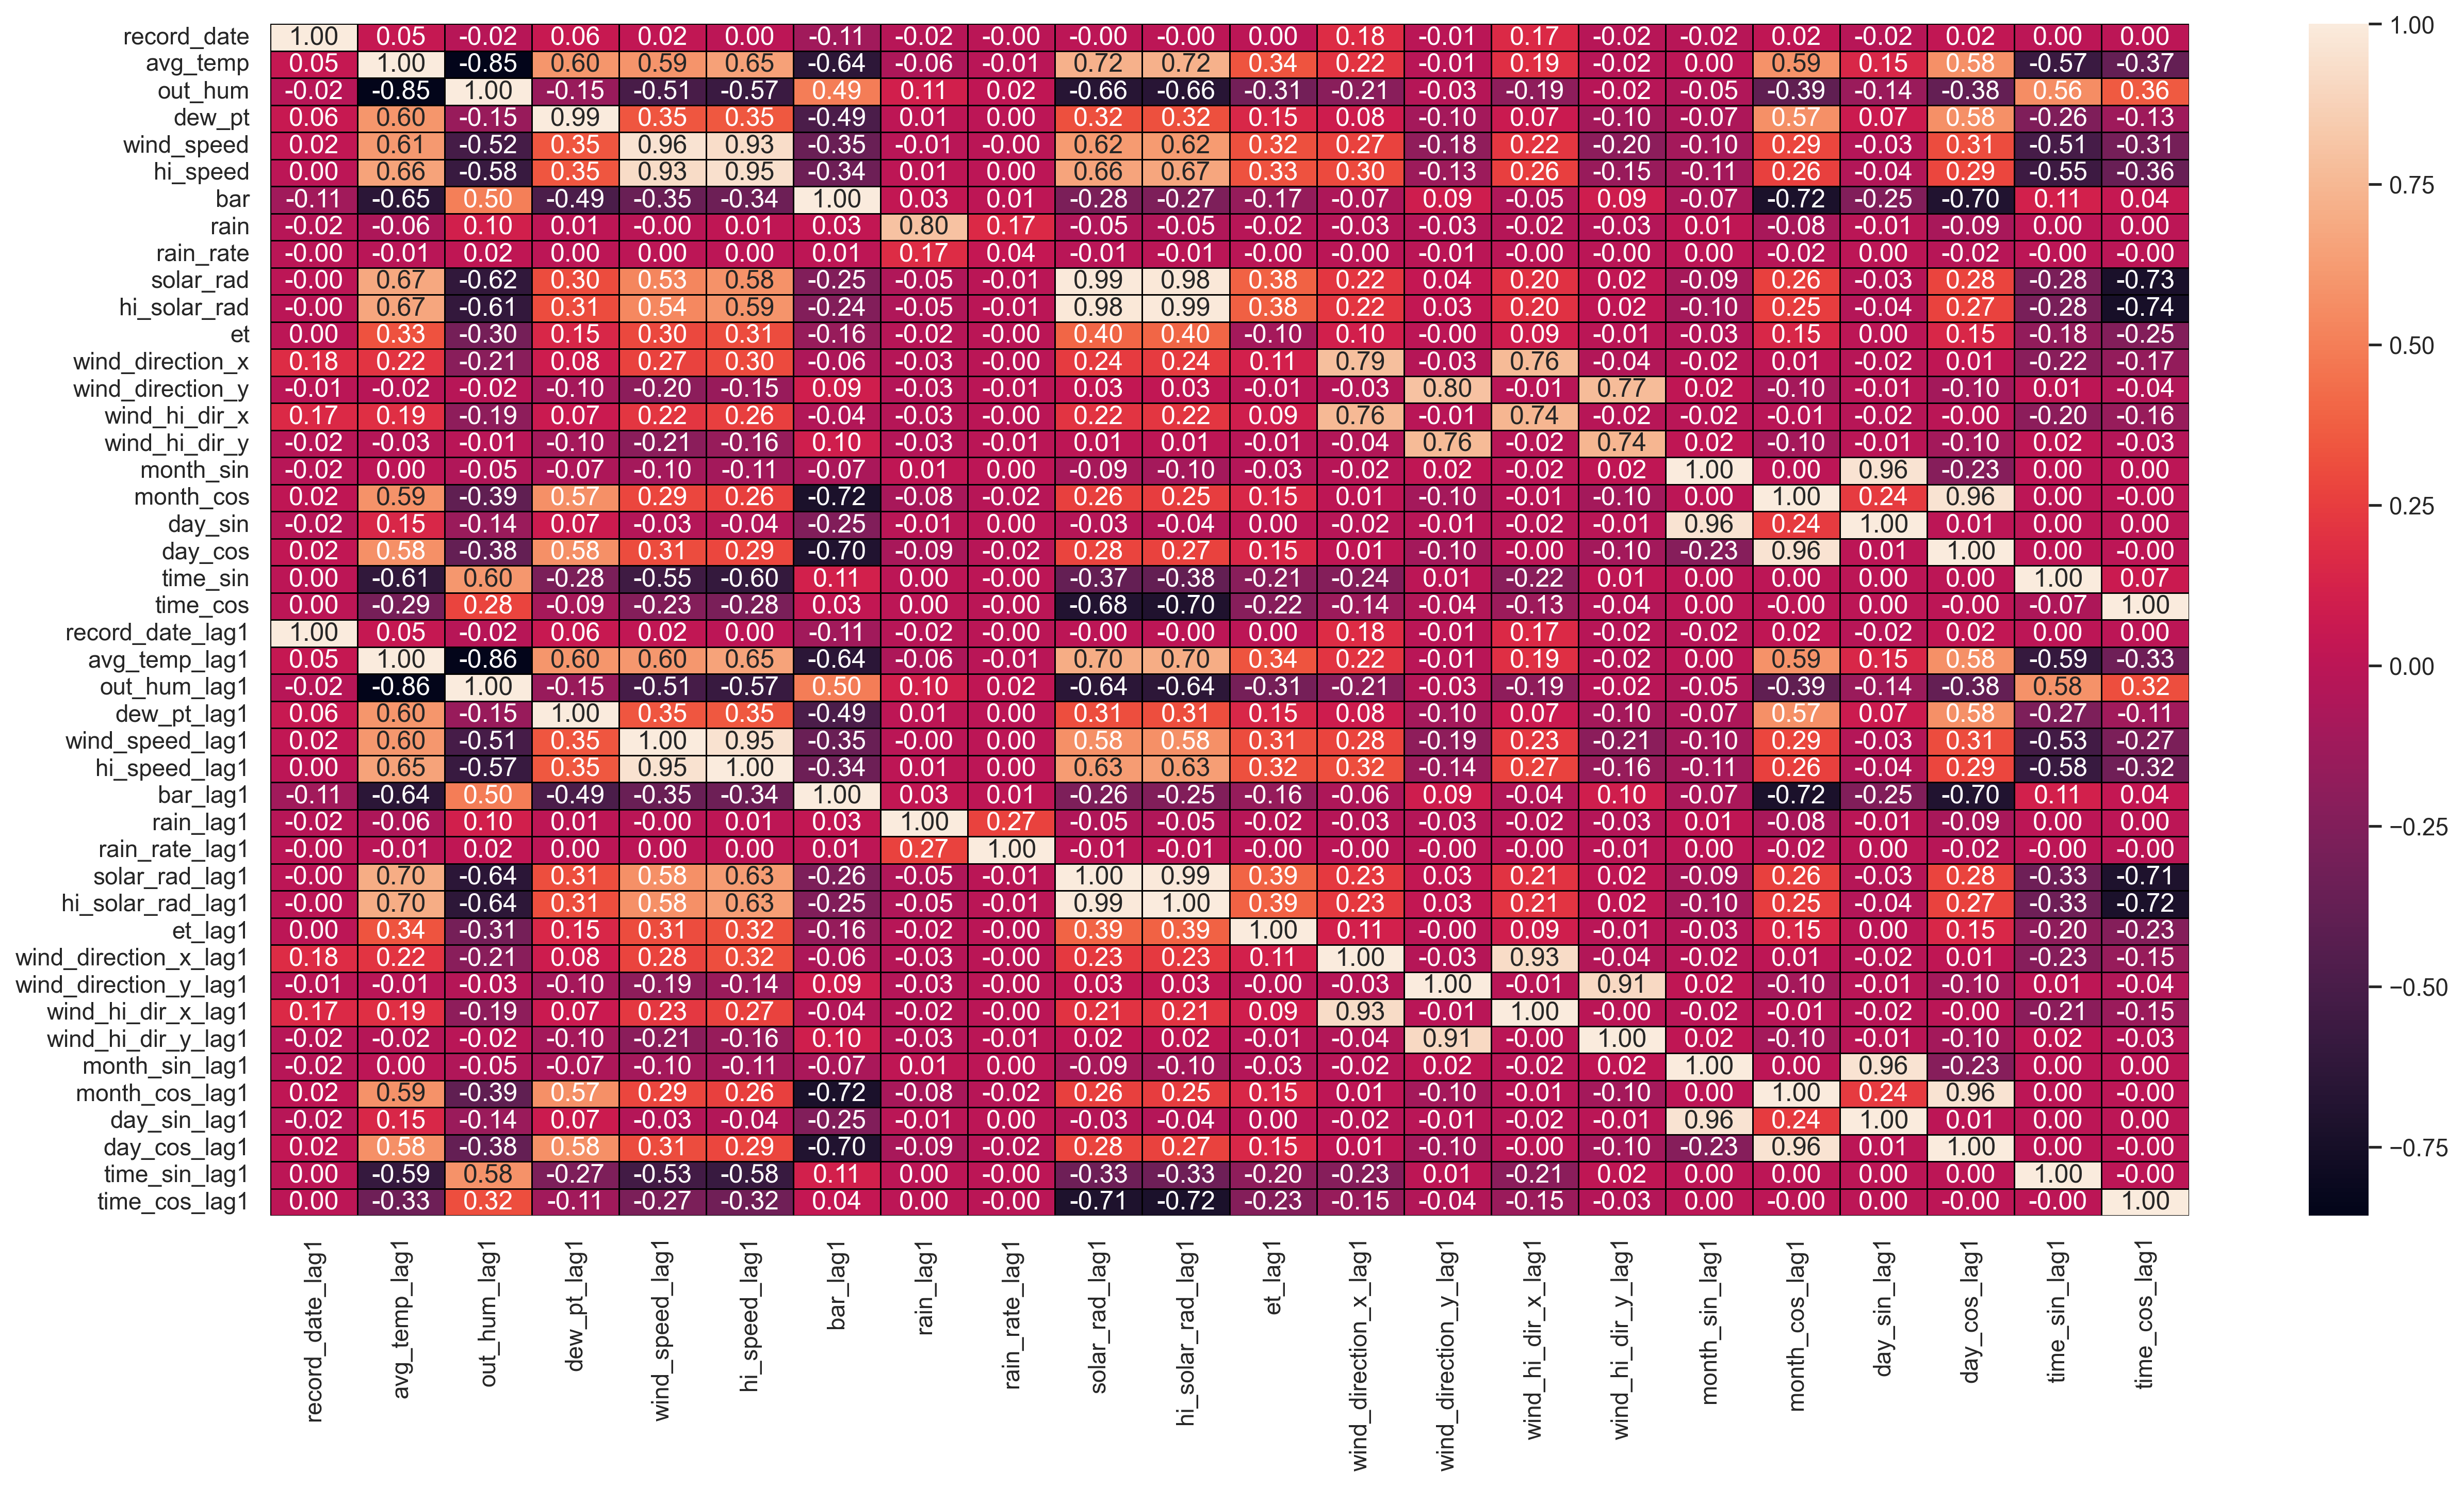

In [8]:
corr_matrix = df.corr()[df.columns[22:]]

plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidth=".25", linecolor="black")

## Removing under performing correlations

<Axes: >

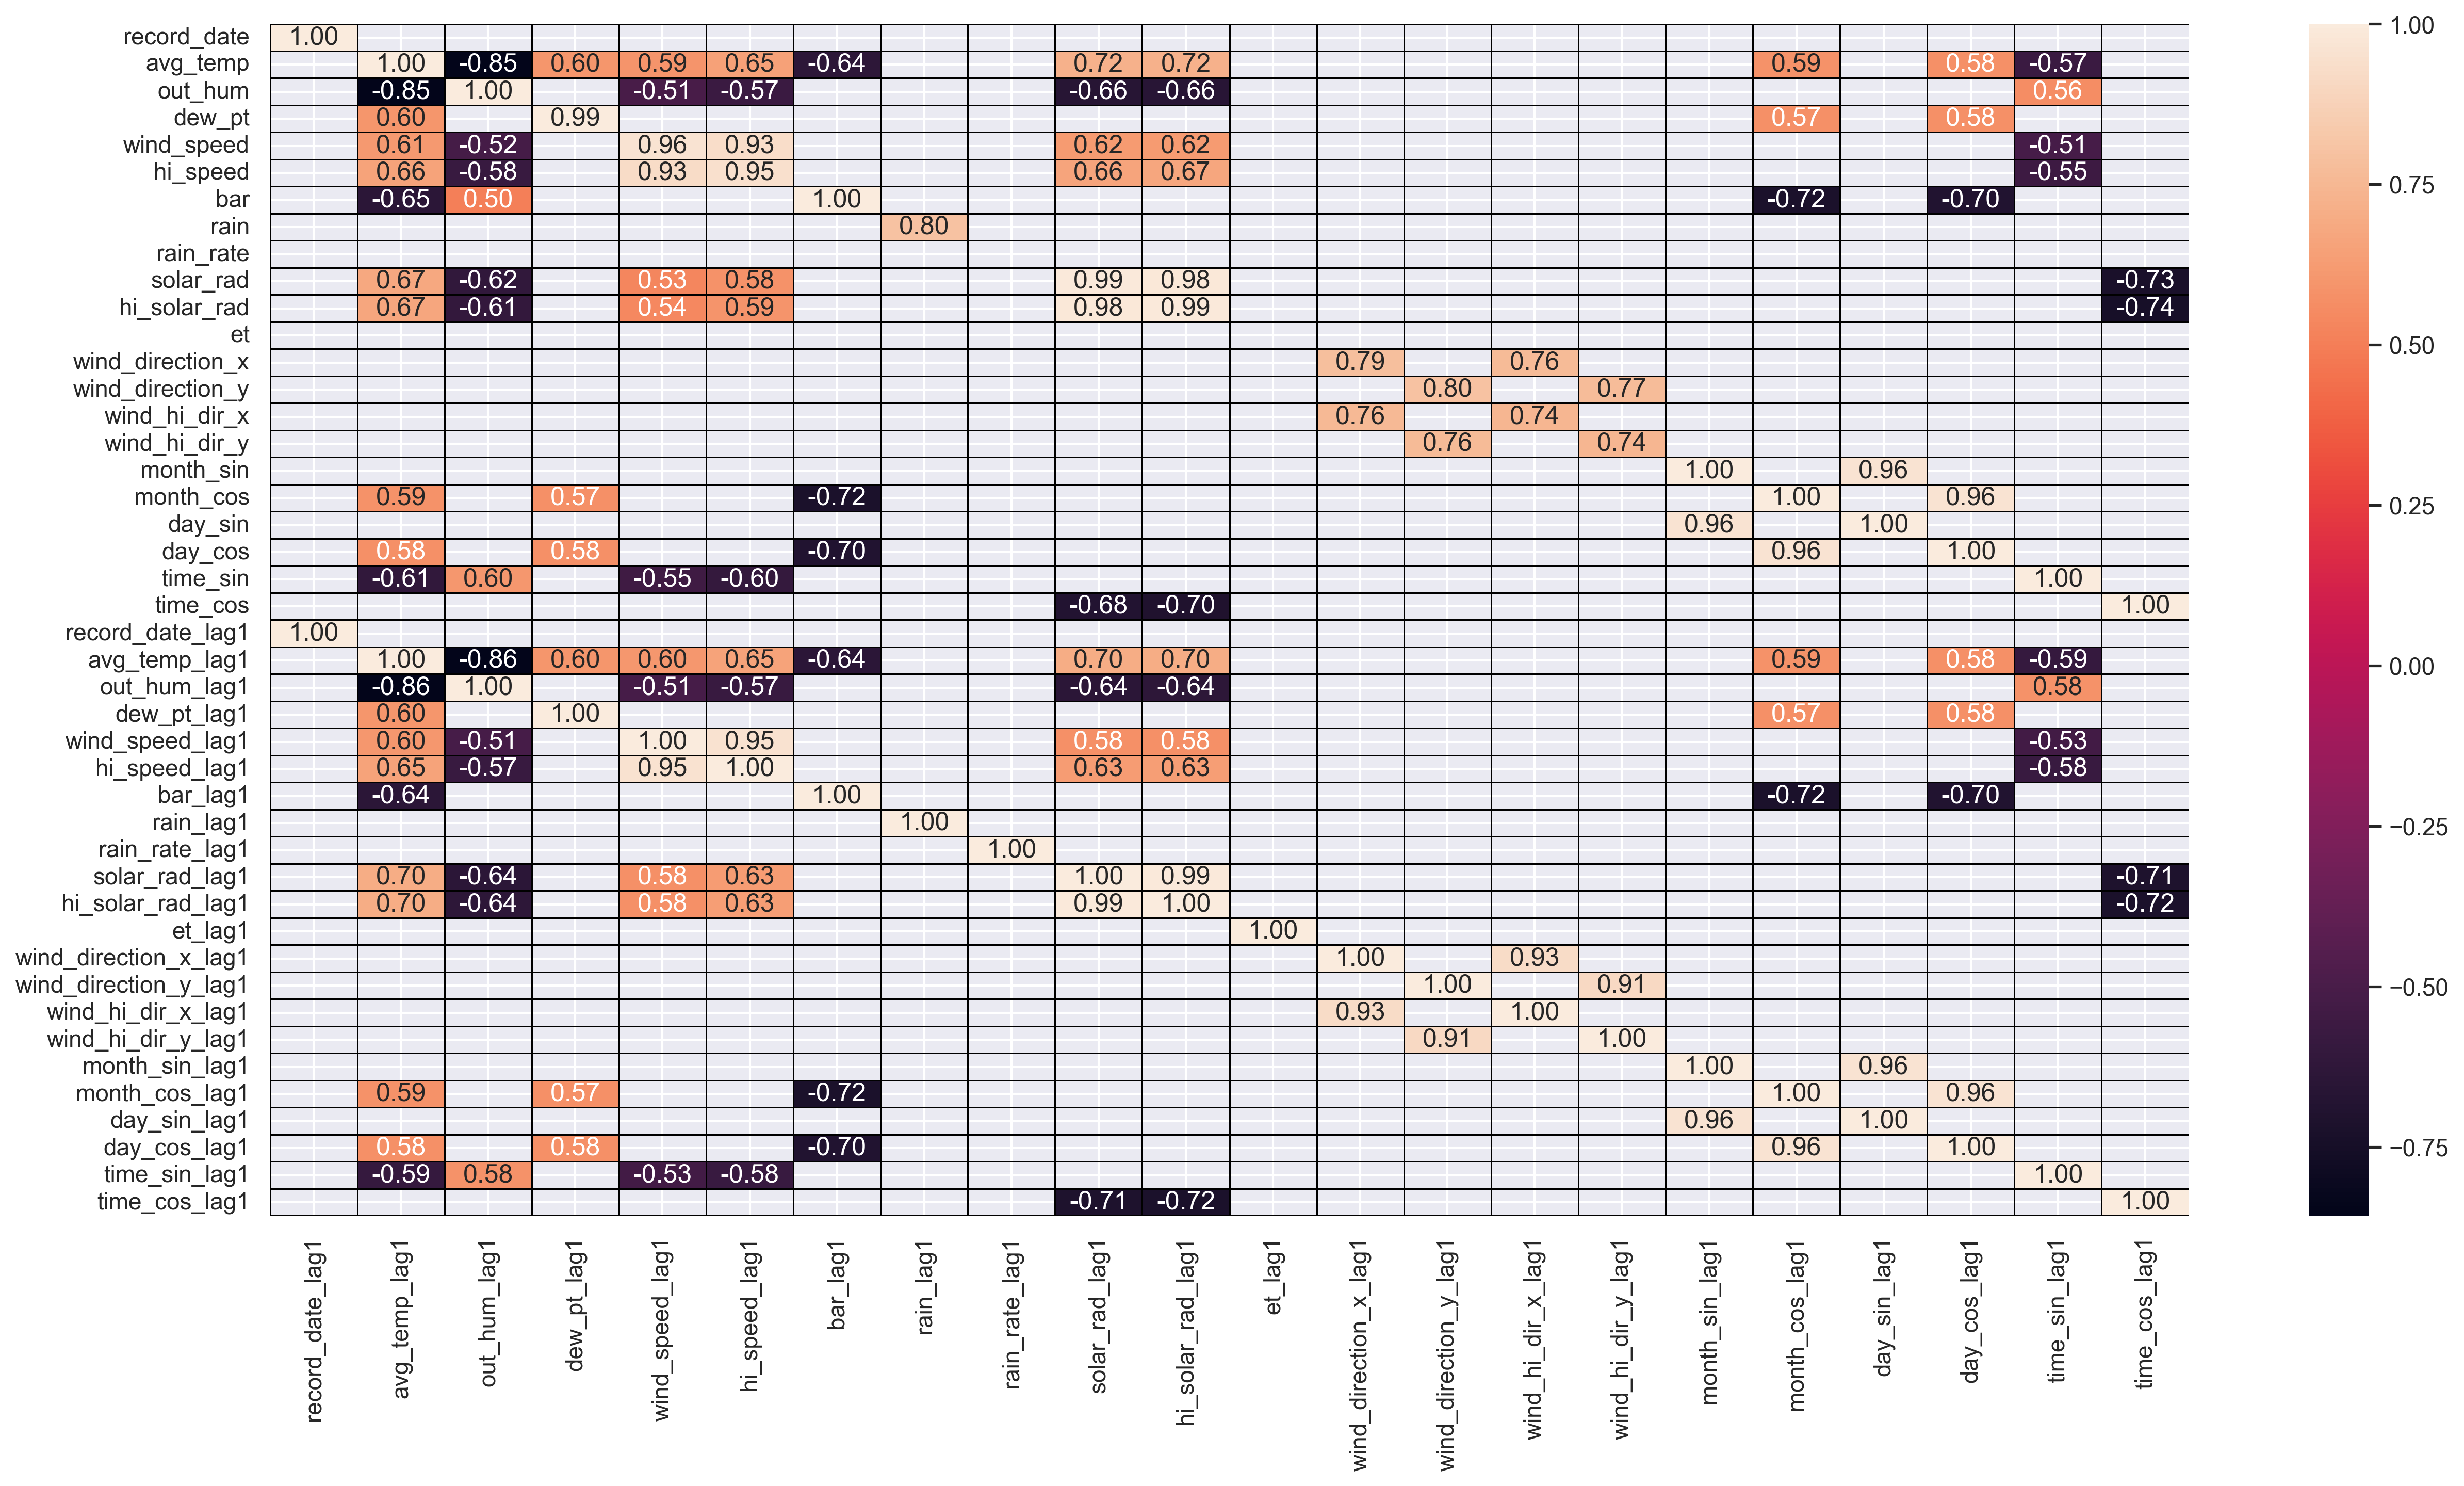

In [9]:
threshold = 0.5
mask = np.abs(corr_matrix) < threshold

plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidth=".25", linecolor="black", mask=mask)

# Linear Regression
Linear regression is a statistical technique used to find the relationship between a dependant variable and one or more independent variables. It predicts continuous values by fitting a straight line that best represents the data.

In this ML context, it finds the relationship between features and a label.

Algebraically, LR would be defined as it follows:

$y' = b + w_nx_n$

Where:
* $y'$ is the predicted label (dependant variable). In our case, the next average temperature.
* $b$ is the bias of the model.
* $w_n$ is the weight of the associated $n$ feature.
* $x_n$ is the value of the $n$ feature (independent variable).

## Training & Evaluation
To evaluate these models, we will use two metrics:

1. **Mean Absolute Error (MAE):** Average difference between predicted values and actual values in a dataset. Shows how far predictions are from the true values.
2. **R-Squared ($R^2$):** How well the data fit a regression line or curve. Ranging from 0 to 1, a higher value indicates a better fit.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Features & Target
features = ["avg_temp_lag1", "out_hum_lag1", "dew_pt_lag1", "wind_speed_lag1",
            "hi_speed_lag1", "bar_lag1", "solar_rad_lag1", "hi_solar_rad_lag1",
            "month_cos_lag1", "day_cos_lag1", "time_sin_lag1"]
target = "avg_temp"
X = df[features]
y = df[target]

# Split
train_size = int(len(df)*0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Training
lr_model = LinearRegression()
lr_model.fit(X_train.values, y_train.values)

# Evaluation
predictions = lr_model.predict(X_test.values)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"LR MAE: {mae:.4f} °C\nLR R2 Score: {r2:.4f}")

LR MAE: 0.3152 °C
LR R2 Score: 0.9970


## Feature Coefficients

In [11]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': np.round(lr_model.coef_,3)
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)

              Feature  Coefficient
0       avg_temp_lag1        0.967
10      time_sin_lag1        0.300
8      month_cos_lag1        0.106
2         dew_pt_lag1        0.029
7   hi_solar_rad_lag1        0.002
4       hi_speed_lag1        0.002
5            bar_lag1        0.002
6      solar_rad_lag1       -0.000
1        out_hum_lag1       -0.006
3     wind_speed_lag1       -0.038
9        day_cos_lag1       -0.146


# Random Forest Regressor
This algorithm builds a "forest" of many individual decision trees (those map out choices and their potential outcomes) and combining their outputs into a single, more accurate result.

Some advantages over LR includes the **handling of non-linearity** (assumed in LR-based models), **more robustness to outliers** (in LR-based models, these may skew the regression line, whereas RFs partitions data into regions) and a **better handling of multicollinearity** (high correlation between features, which is done by randomly selecting a subset of features for each tree split).

## Training & Evaluation

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train.values, y_train.values)

rf_preds = rf_model.predict(X_test.values)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print(f"Random Forest MAE: {rf_mae:.4f} °C")
print(f"Random Forest R2 Score: {rf_r2:.4f}")

Random Forest MAE: 0.2371 °C
Random Forest R2 Score: 0.9984


## Feature Coefficients

              Feature  Importance
0       avg_temp_lag1    0.996644
7   hi_solar_rad_lag1    0.001214
6      solar_rad_lag1    0.001031
10      time_sin_lag1    0.000858
4       hi_speed_lag1    0.000095
5            bar_lag1    0.000041
3     wind_speed_lag1    0.000032
8      month_cos_lag1    0.000029
9        day_cos_lag1    0.000025
1        out_hum_lag1    0.000019
2         dew_pt_lag1    0.000011


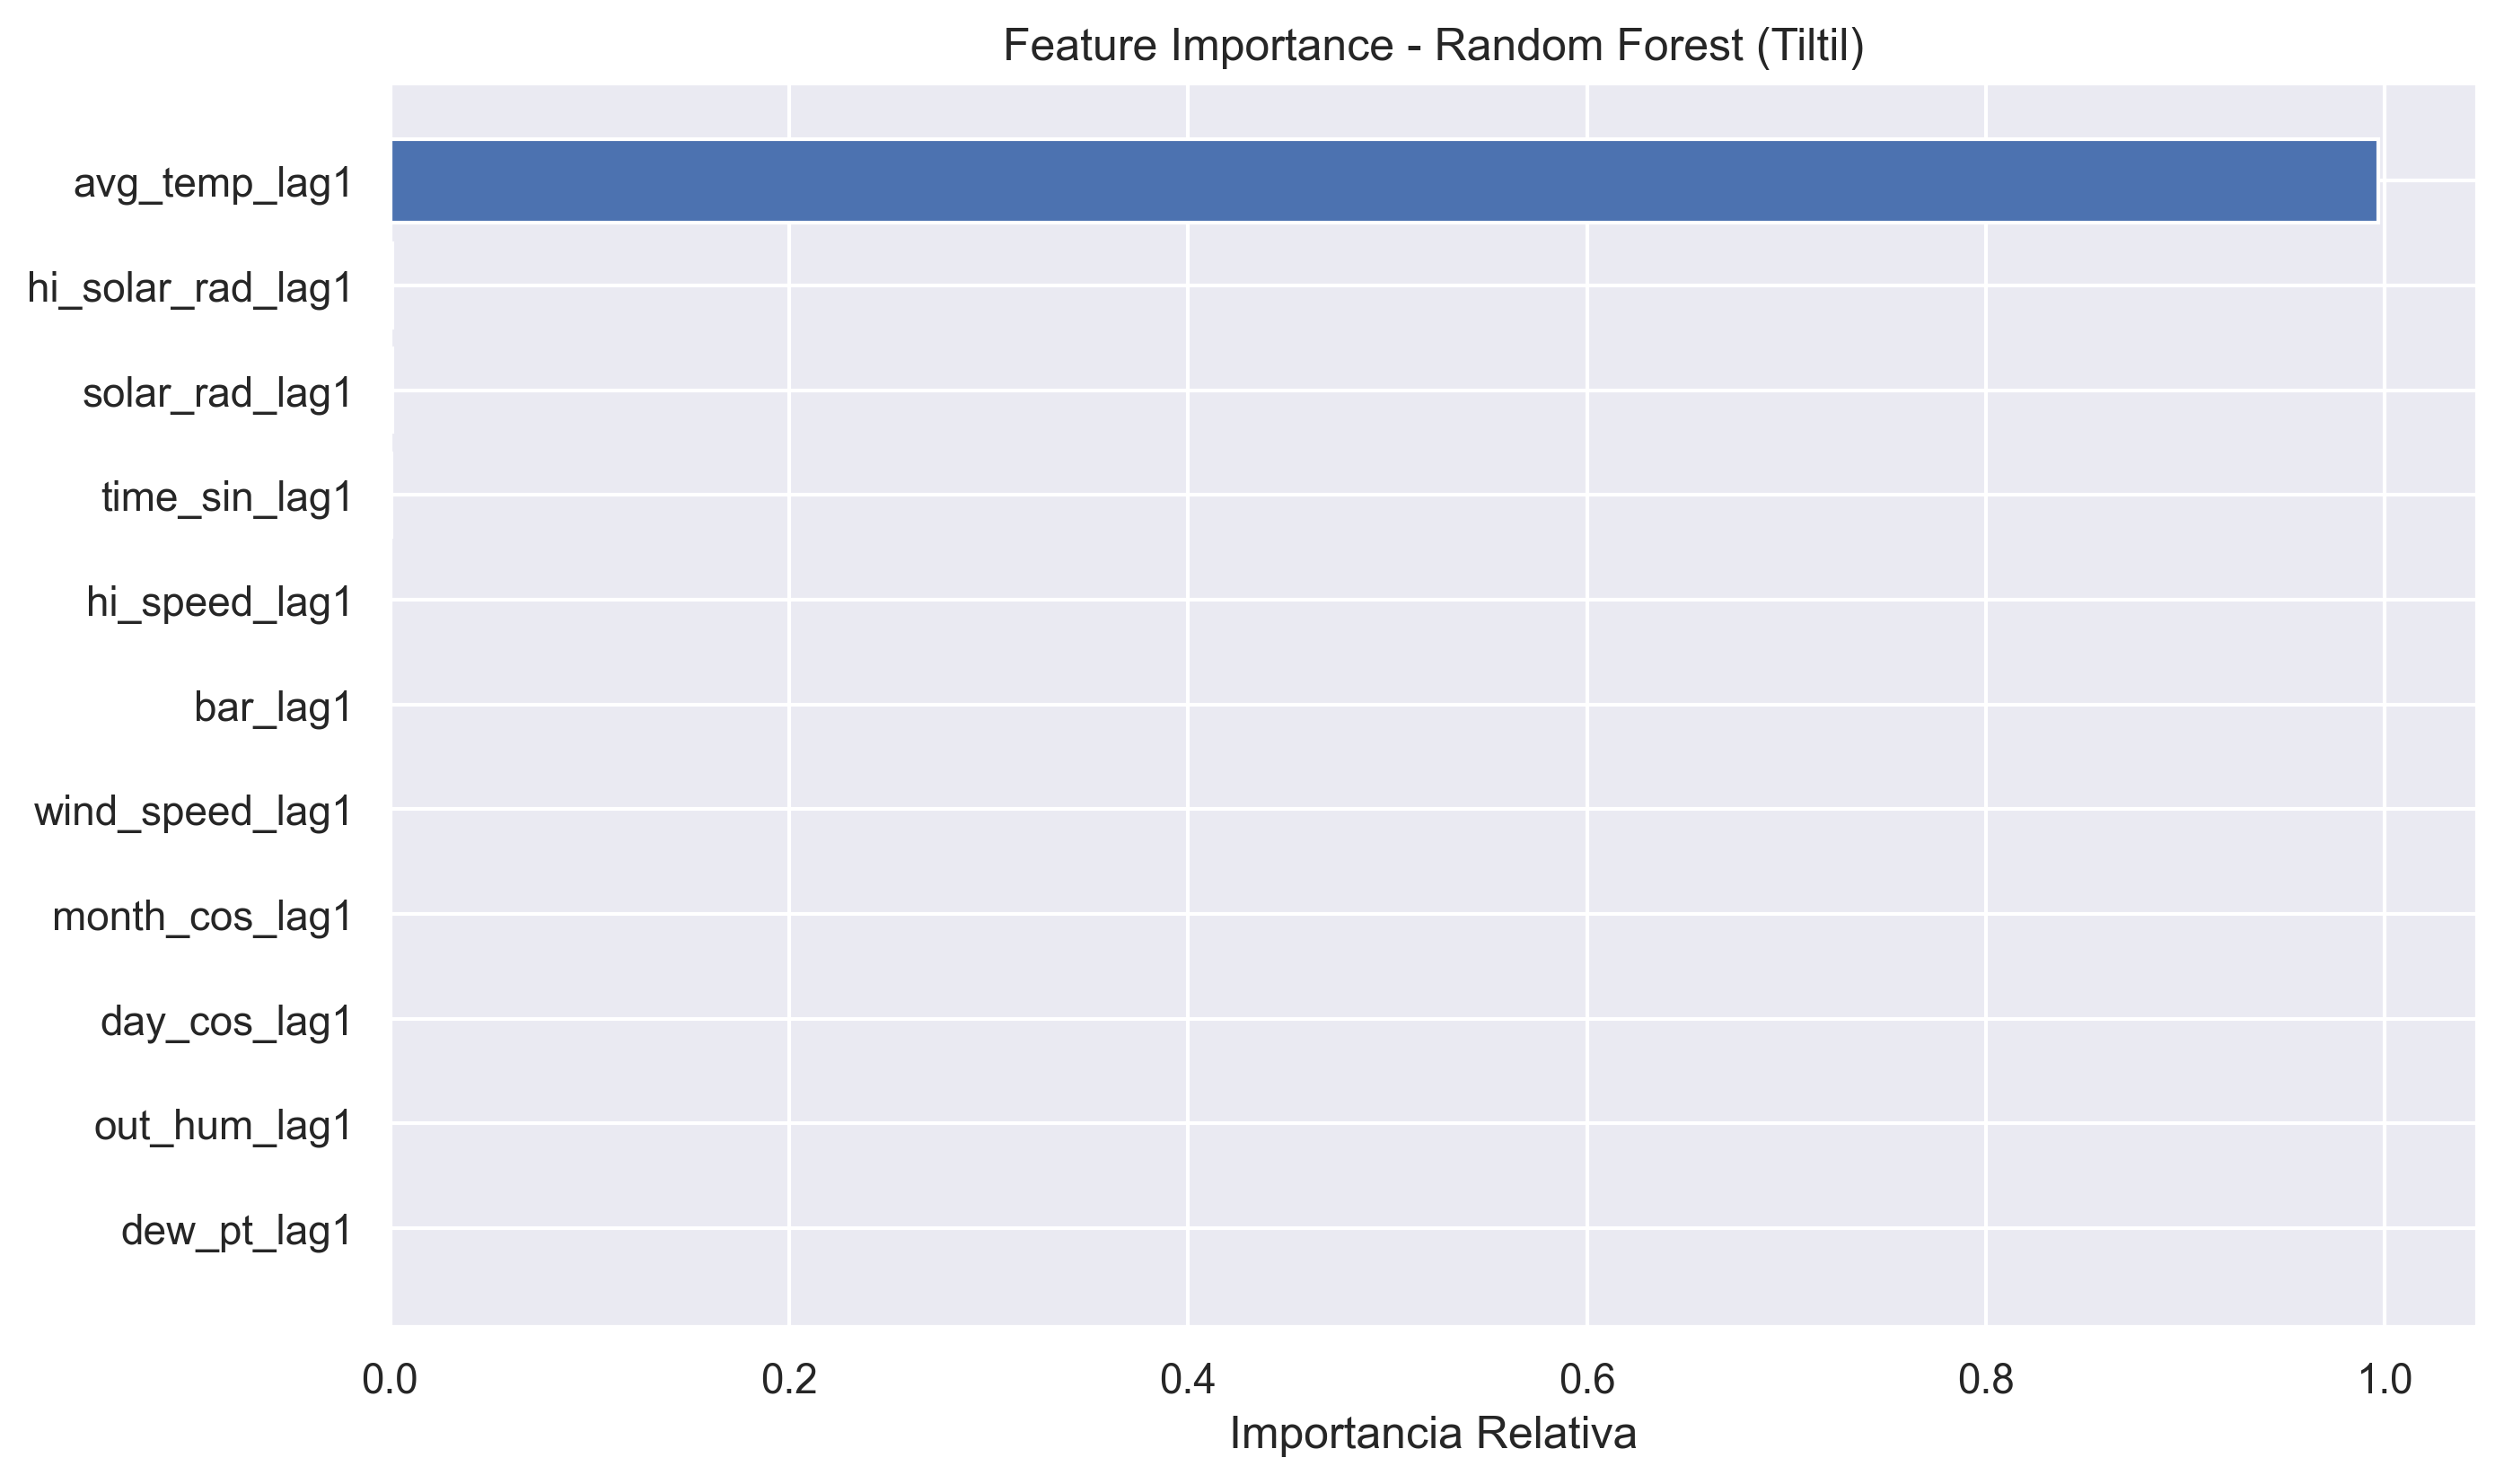

In [13]:
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importancia Relativa')
plt.title('Feature Importance - Random Forest (Tiltil)')
plt.gca().invert_yaxis()
plt.show()

# XGBoost
eXtreme Gradient Boosting (XGBoost) uses decision trees with gradient, a boosting algorithm that uses gradient descent (an algorithm that trains ML models through the minimization of errors between predicted and real results).

Decision trees tend to overfit, this ensemble methods may help to create more robusts models. Boosting combines multiple individual weak trees and form a strong learner: each weak learner is trained sequentially to correct the errors made by the previous models, later becoming strong learners.

In [14]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

xgb_model = xgb.XGBRegressor(
    n_estimators=10000,
    learning_rate=0.01,
    max_depth=5,
    n_jobs=-1,
    random_state=42,
    eval_metric="mae",
    early_stopping_rounds=500,
)

xgb_model.fit(
    X_train.values, y_train.values,
    eval_set=[(X_test.values, y_test)],
    verbose=False
)

xgb_preds = xgb_model.predict(X_test.values)
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_r2 = r2_score(y_test, xgb_preds)

print(f"XGBoost MAE: {xgb_mae:.4f} °C")
print(f"XGBoost R2 Score: {xgb_r2:.4f}")

XGBoost MAE: 0.2206 °C
XGBoost R2 Score: 0.9986


              Feature  Importance
0       avg_temp_lag1    0.993970
7   hi_solar_rad_lag1    0.001877
6      solar_rad_lag1    0.001729
10      time_sin_lag1    0.001259
4       hi_speed_lag1    0.000332
8      month_cos_lag1    0.000299
3     wind_speed_lag1    0.000248
2         dew_pt_lag1    0.000105
1        out_hum_lag1    0.000071
5            bar_lag1    0.000062
9        day_cos_lag1    0.000048


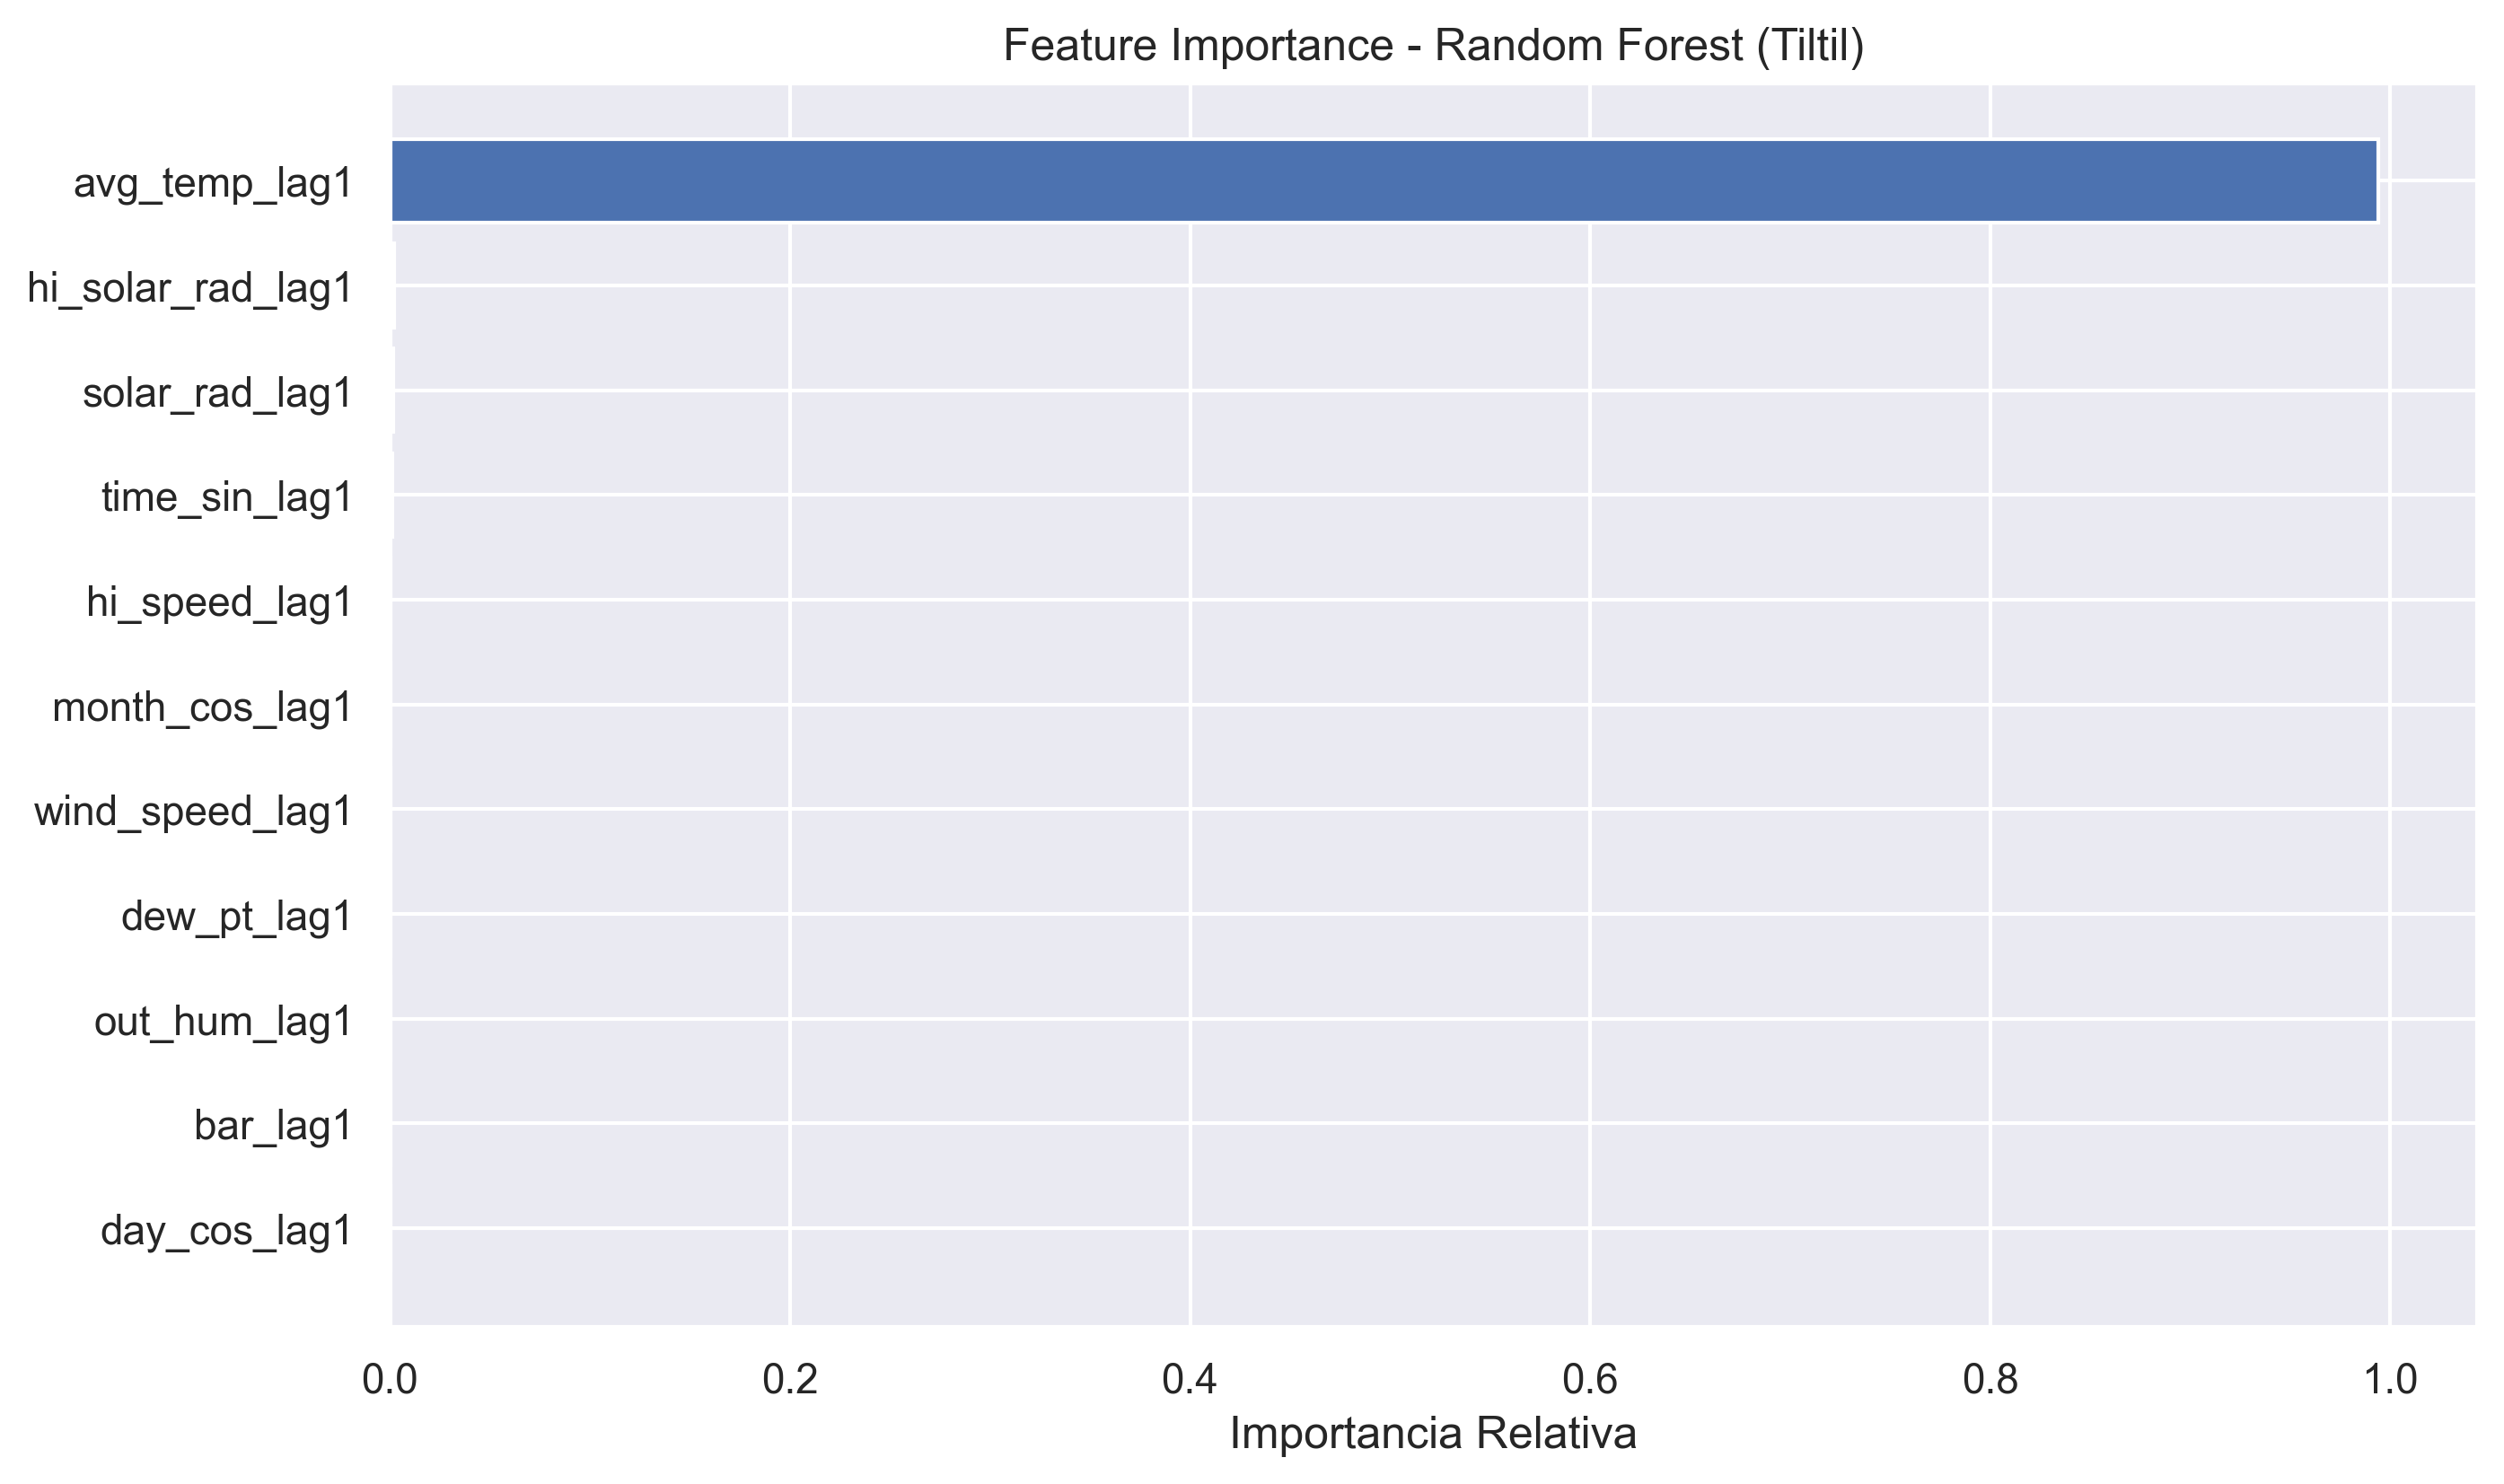

In [15]:
importances = xgb_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importancia Relativa')
plt.title('Feature Importance - Random Forest (Tiltil)')
plt.gca().invert_yaxis()
plt.show()

# Predictions

In [16]:
initial_num = -256

df_real_pred = df.iloc[:, [0,1]][initial_num:]
df_with_features = df.iloc[:, [23,24,25,26,27,28,31,32,39,41,42]][initial_num:]

df_with_features["next_temp_15min"] = np.round(rf_model.predict(df_with_features.values),5)
df_real_pred["avg_temp_pred_rf"] = df_with_features["next_temp_15min"].shift(1)
df_with_features.drop(columns="next_temp_15min", inplace=True)

df_with_features["next_temp_15min"] = np.round(lr_model.predict(df_with_features.values),5)
df_real_pred["avg_temp_pred_lr"] = df_with_features["next_temp_15min"].shift(1)
df_with_features.drop(columns="next_temp_15min", inplace=True)

df_with_features["next_temp_15min"] = np.round(xgb_model.predict(df_with_features.values),5)
df_real_pred["avg_temp_pred_xgb"] = df_with_features["next_temp_15min"].shift(1)
df_with_features.drop(columns="next_temp_15min", inplace=True)

df_real_pred.dropna(inplace=True)

display(df_real_pred)

,record_date,avg_temp,avg_temp_pred_rf,avg_temp_pred_lr,avg_temp_pred_xgb
632154,2026-04-26 01:15:00,6.8,7.13071,7.21467,7.075350
632155,2026-04-26 01:30:00,6.6,7.03147,7.19253,6.920110
632156,2026-04-26 01:45:00,6.2,6.63897,6.81580,6.545000
632157,2026-04-26 02:00:00,5.9,6.41139,6.63435,6.335460
632158,2026-04-26 02:15:00,5.7,6.09219,6.25093,5.946280
...,...,...,...,...,...
632404,2026-04-28 16:00:00,25.2,26.59899,26.20991,26.304729
632405,2026-04-28 16:15:00,24.7,25.42574,25.06087,25.169060
632406,2026-04-28 16:30:00,24.0,24.95766,24.76593,24.844761
632407,2026-04-28 16:45:00,22.8,24.41988,24.22744,24.289101


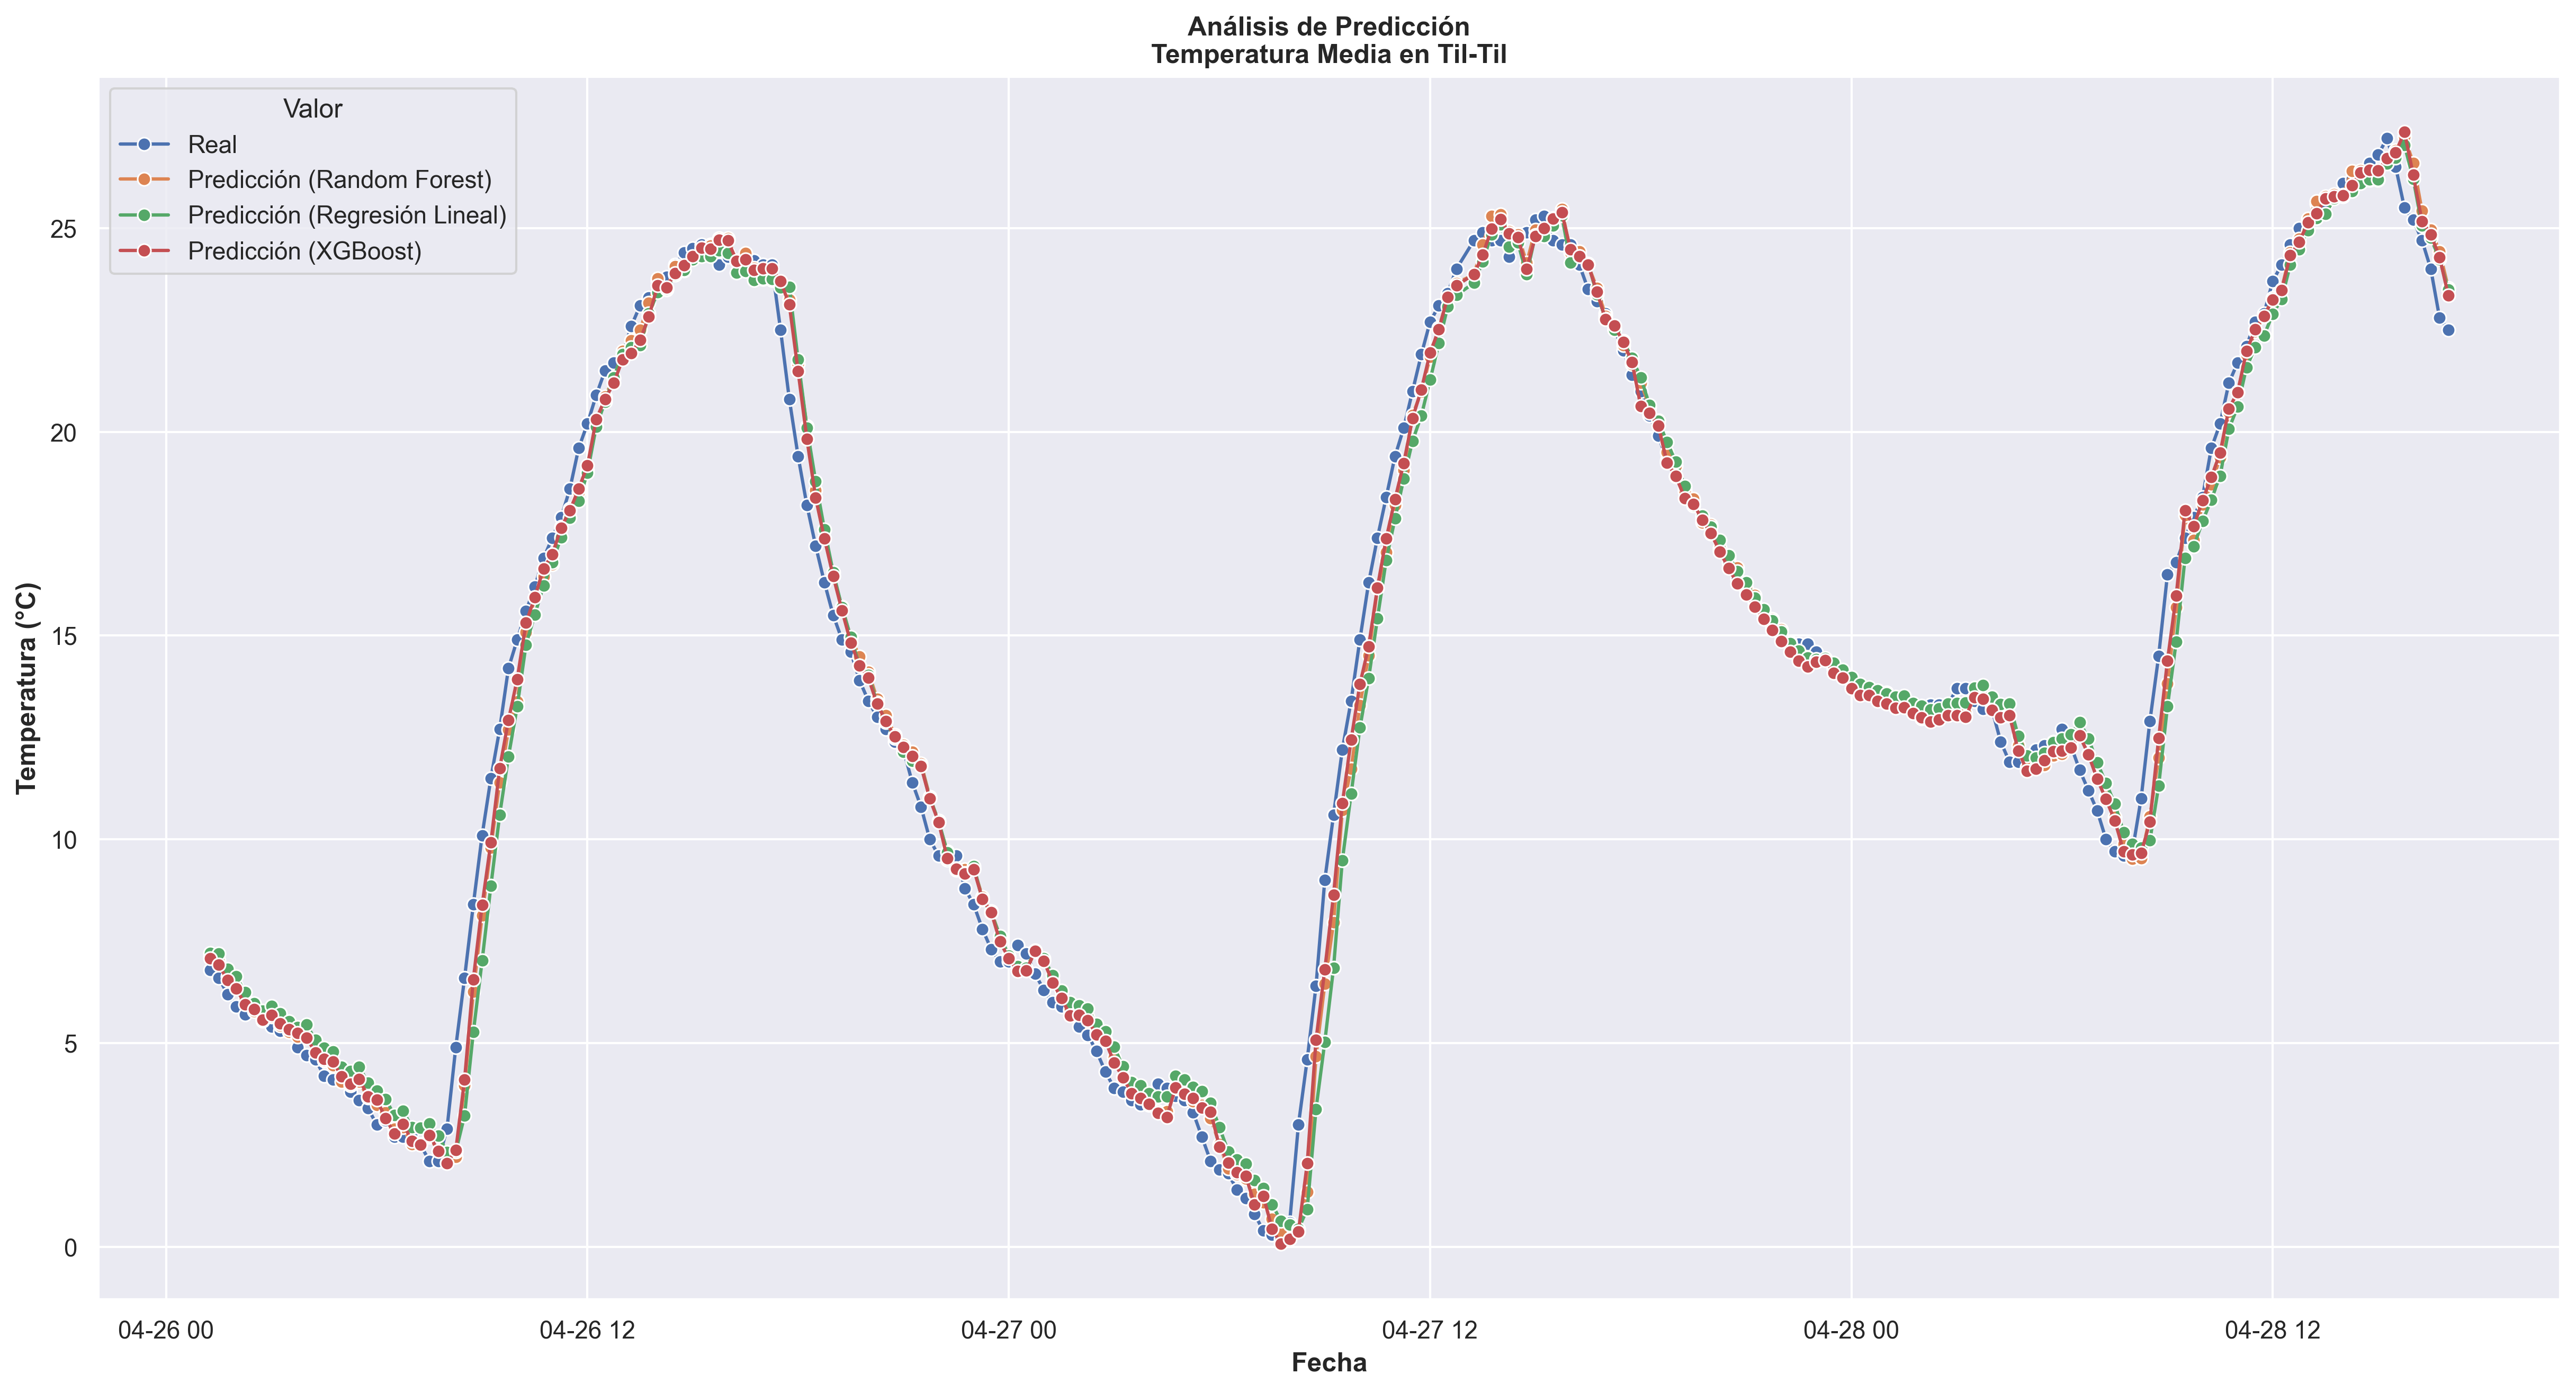

In [17]:
# Melting
df_plot = df_real_pred.melt(id_vars=['record_date'], 
                            value_vars=['avg_temp', 'avg_temp_pred_rf', 'avg_temp_pred_lr', 'avg_temp_pred_xgb'], 
                            var_name='Valor', 
                            value_name='Temperatura (°C)')

df_plot['Valor'] = df_plot['Valor'].map({
    'avg_temp': 'Real',
    'avg_temp_pred_rf': 'Predicción (Random Forest)',
    'avg_temp_pred_lr': 'Predicción (Regresión Lineal)',
    'avg_temp_pred_xgb': 'Predicción (XGBoost)'
})

plt.figure(figsize=(20, 10))

g = sns.lineplot(data=df_plot, x="record_date", y="Temperatura (°C)", hue="Valor", marker="o")

plt.title("Análisis de Predicción\nTemperatura Media en Til-Til", fontweight="bold")
plt.xlabel("Fecha", fontweight="bold")
plt.ylabel("Temperatura (°C)", fontweight="bold")
plt.show()

# Exporting models

In [18]:
import pickle

with open("./ml_models/modelo_tiltil_xgb.pkl", "wb") as f:
    pickle.dump(xgb_model, f)
with open("./ml_models/modelo_tiltil_rf.pkl", "wb") as f:
    pickle.dump(rf_model, f)
with open("./ml_models/modelo_tiltil_lr.pkl", "wb") as f:
    pickle.dump(lr_model, f)

|       Model       | MAE (°C) |  $R^2$ | Size (Pickle) |
|:-----------------:|:--------:|:------:|:-------------:|
| Linear Regression |  0.3152  |  0.997 |     ~1 Kb     |
|   Random Forests  |  0.2371  | 0.9984 |     ~14 Mb    |
|      XGBoost      |  0.2206  | 0.9986 |     ~25 Mb    |